# ANALYSE STATISTIQUE DES PERFORMANCES

Ce notebook seviras à répondre à la question de comprendre les données de NexaCommerce 
et de voir les corrélations significative.
Dans ce notebook on retrouveras :    

1. les statistiques descriptives (moyenne, médianne, écart-type,quartilles) des temps de livraison par ville, 

2. Représentation des distrubitions avec les histogrammes (matplotlib) et boxplots (seaborn),

3. L'application du théorème de Bayes,

4. Réalisation des tests de Students,

5. Les matrice de corrélation entre les données,

6. Détecter les valeur abérantes.

**Objectifs** : *Comprendre les données de NexaCommerce*

## Chargement des données de NexaCommerce

Ce que nous fesons icit : 
 - Nous importont toutes les `biblothèques` que nous allons devoir utiliser dans notre notebook,

 - Utilisation de fichier à travers notre module `nexacommerce` depuis `config`,
 
 - Enfin charger les datasets à travers notre classe `CSVLoader` créer.

In [111]:
from nexacommerce.config import *
from nexacommerce.data_loader import CSVLoader 
from nexacommerce.inspection import inspect_dataset
from datetime import datetime
from scipy.stats import ttest_ind
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re

order_loader =CSVLoader(ORDERS_FILE)
order_items_loader = CSVLoader(ORDER_ITEMS_FILE)
courier_loader = CSVLoader(COURIERS_FILE)
customer_loader = CSVLoader(CUSTOMERS_FILE)

orders = order_loader.load()
customers = customer_loader.load()
couriers = courier_loader.load()
orders_item = order_items_loader.load() 

### Verification 
Ici on vérifie si les fichiers sont charger et pris en charge et qu'ils sont correctent

In [112]:
print(f"Ligne et colonne des fichiers : ")
print(f"orders = {orders.shape}")
print(f"customers = {customers.shape}")
print(f"orders_items = {orders_item.shape}")
print(f"couriers = {couriers.shape}")

Ligne et colonne des fichiers : 
orders = (12500, 12)
customers = (2380, 7)
orders_items = (30975, 8)
couriers = (47, 8)


## Préparation de la données
Pendant nos manipulation en SQL sur les tables nous avons réaliser que les données des tables de la base de données nexacommerce était salle ( avec des doublons, des valeurs null, des valeurs non normalisé, valeurs incorectes ... ). Ici ce que nous allons faire : 

- Identifier les valeurs non correctes,

- normalisation des valeurs.


### Identification des valeurs non correctes et manquantes 


In [113]:
# Inspection des valeurs sur orders 
inspection_orders = inspect_dataset(orders)
# Inspection des valeurs sur customers
inspection_customer = inspect_dataset(customers) 

print(display(inspection_customer))

# Isoler la colonne dans la variable status_cols 
status_cols = [c for c in orders.columns if c.lower()=="status"]

if status_cols:     
    for c in status_cols:
        ## Afficher les valeurs unique de la colonne
        print(f"\Colonne: {c} — nombre de valeur Unique:", orders[c].nunique(dropna=False))
        print(orders[c].astype(str).str.strip().value_counts(dropna=False).head(200))
else:
    print("La colonne n'existe pas")
    
   
# Distinction des dates   
date_cols = [c for c in orders.columns if "date" in c.lower()]
if not date_cols:
    print("\nAucune colonne contenant 'date'")
else:
    for c in date_cols:
        print(f"\Collone: {c} — Valeur distinctes :", orders[c].nunique(dropna=False))
        print(orders[c].astype(str).str.strip().value_counts(dropna=False))        
        
        
# Distinction des villes
city_cols = [c for c in orders.columns if c.lower() == "city"] 

if city_cols:
    for c in city_cols:
        print(f"n\Colonne: {c} - Nombre de valeur unique: ",orders[c].nunique(dropna=False))
        print(orders[c].astype(str).str.strip().value_counts(dropna=False))
else:
    print("La colonne n'existe pas")    
    
    
# Nombre doublons de téléphone dans la table Order
doublons = customers[customers['phone'].notna()].duplicated(subset='phone', keep=False)
print(f'\nClients avec doublons téléphone : {doublons.sum()}')        

{'n_rows': 2380,
 'n_cols': 7,
 'dtypes': {'customer_id': 'str',
  'name': 'str',
  'phone': 'str',
  'registration_date': 'str',
  'city': 'str',
  'quartier': 'str',
  'loyalty_score': 'float64'},
 'missing_counts': {'customer_id': 0,
  'name': 0,
  'phone': 0,
  'registration_date': 0,
  'city': 0,
  'quartier': 0,
  'loyalty_score': 151},
 'missing_percentages': {'customer_id': 0.0,
  'name': 0.0,
  'phone': 0.0,
  'registration_date': 0.0,
  'city': 0.0,
  'quartier': 0.0,
  'loyalty_score': 6.34},
 'columns_with_missing': ['loyalty_score'],
 'duplicate_count': 0,
 'duplicate_percentage': 0.0}

None
\Colonne: status — nombre de valeur Unique: 17
status
livrÃ©       7563
en_retard    2429
annulÃ©       978
en_cours      286
LivrÃ©        261
livre         144
LIVRE         135
En_retard     131
en retard     119
AnnulÃ©        73
en cours       70
En_cours       69
EN_RETARD      62
ANNULE         61
retard         61
annule         58
Name: count, dtype: int64
\Collone: order_date — Valeur distinctes : 11194
order_date
14-03-2025             9
11-03-2025             8
02-05-2024             8
17-01-2025             8
26-12-2024             8
                      ..
2023-10-20 19:35:00    1
22/05/2024 19:42       1
2023/02/07 18:26       1
06 May 2023            1
05/10/2023 13:19       1
Name: count, Length: 11194, dtype: int64
n\Colonne: city - Nombre de valeur unique:  14
city
Douala       2604
douala       2586
YaoundÃ©     1684
DOUALA       1232
Bafoussam    1007
yaounde       833
Yaounde       812
YAOUNDE       806
bafoussam     479
BAFOUSSAM     457
Name: count, dtype:

### Normalisation
Nous allons definir des fonctions de normalisation pour nos donnés et les appliques à notre table 

In [115]:
# Les fonctions de normsalisation 

# Normalise les status
def status_normalise(value):
    
    if pd.isna(value):
        return np.nan
    
    value = str(value).strip().lower()
    if value in {"livrÃ©", "LivrÃ©", "LIVRE", "livre", "livré", "livrã©"}:
        return "delivered"
    if value in {"en_retard", "en retard", "retard", "En_retard", "EN_RETARD"}:
        return "late"
    if value in {"annule", "ANNULE", "AnnulÃ©", "annulÃ©","annulã©"}:
        return "cancelled"
    if value in {"en_cours", "en cours","En_cours"}:
        return "in_progress"
    return value.strip().lower()

# Normalisé les numéros téléphone 
def normalise_phone(phone):
    if pd.isna(phone): 
        return None
    # Supprimer tout ce qui n'est pas un chiffre
    digits = re.sub(r'\D', '', str(phone))
    # Retirer le préfixe international 237
    if digits.startswith('237') and len(digits) == 12:
        digits = digits[3:]
    # Doit faire 9 chiffres et commencer par 6 ou 2
    if len(digits) == 9 and digits[0] in ('6', '2'):
        return digits
    return None # Format non reconnu


# Normalisé les villes
def city_normalise(value):
    if pd.isna(value):
        return np.nan
    if value in {"Yaoundã©","Yaoundã©","YaoundÃ©","YaoundÃ©","YaoundÃ©","Yaounde", "yaounde","yaoundã©"}:
        return "Yaounde"
    if value in {"DOUALA", "Douala", "douala","douala","douala"}:
        return "Douala"
    if value in {"BAFOUSSAM", "Bafoussam","Bafoussam","bafoussam"}:
        return "Bafoussam"     
    value = str(value).strip().lower()
    return value    

# Identifier les formats data de Orders : 
DATE_FORMATS = [
    "%Y-%m-%d %H:%M:%S",
    "%Y/%m/%d %H:%M",
    "%d/%m/%Y %H:%M",
    "%d-%m-%Y %H:%M",    
    "%Y-%m-%d",
    "%Y/%m/%d",
    "%d/%m/%Y",
    "%d-%m-%Y",
    "%d %B %Y",
    "%m/%d/%Y",
    "%m-%d-%Y",    
    "%m/%d/%Y %H:%M",
]  


# Normalisé les dates
def date_normalise(value):
    if pd.isna(value):
        return pd.NaT 
    
    value = str(value).strip()
    for fmt in DATE_FORMATS:
        try:
            return pd.to_datetime(datetime.strptime(value, fmt))
        except ValueError:
            continue

    return pd.NaT 


orders['status'] = orders['status'].apply(status_normalise)
orders ['city'] = orders['city'].apply(city_normalise)
orders['order_date'] = orders['order_date'].apply(date_normalise)

orders["delivery_time_min"] = pd.to_numeric(orders["delivery_time_min"], errors="coerce")
# orders["total_amount_xaf"] = pd.to_numeric(
#     orders["total_amount_xaf"], errors="coerce"
# ).abs()

# customers["loyalty_score"] = pd.to_numeric(customers["loyalty_score"], errors="coerce")



## Statisique descriptives
Nous allons calculez les statistiques descriptives (moyenne, médiane, écart-type, quartiles) des temps de livraison
par ville. et faire : 
- Representaion des distributions avec des histogrammes (matplotlib)

- Representation des distributions avec des boxplots (seaborn)  

In [116]:
# Faire une table pour l'analyse descriptive

stats_desc = (
    orders
    .groupby("city")["delivery_time_min"]
    #Appliquer plusieurs fonction d'agrégation 
    .agg(
        nombre="count",
        moyenne="mean",
        medianne="median",
        exact_type="std",
        quartille25=lambda s: s.quantile(0.25),
        quartille75=lambda s: s.quantile(0.75)
    )
    .reset_index()
)

stats_desc["interQuartille"] = stats_desc["quartille75"] - stats_desc["quartille25"]
stats_desc.round(2)





,city,nombre,moyenne,medianne,exact_type,quartille25,quartille75,interQuartille
0,Bafoussam,1646,51.56,36.0,41.47,25.7,62.92,37.22
1,Douala,5442,64.09,43.2,53.58,31.6,78.20,46.60
2,Yaounde,3519,78.78,53.1,65.05,38.4,98.95,60.55


Cette petite stats nous apprends que Bafoussam est la ville la plus rapide, suivie de Douala et enfin Yaoundé

#### distribution avec des histogrammes


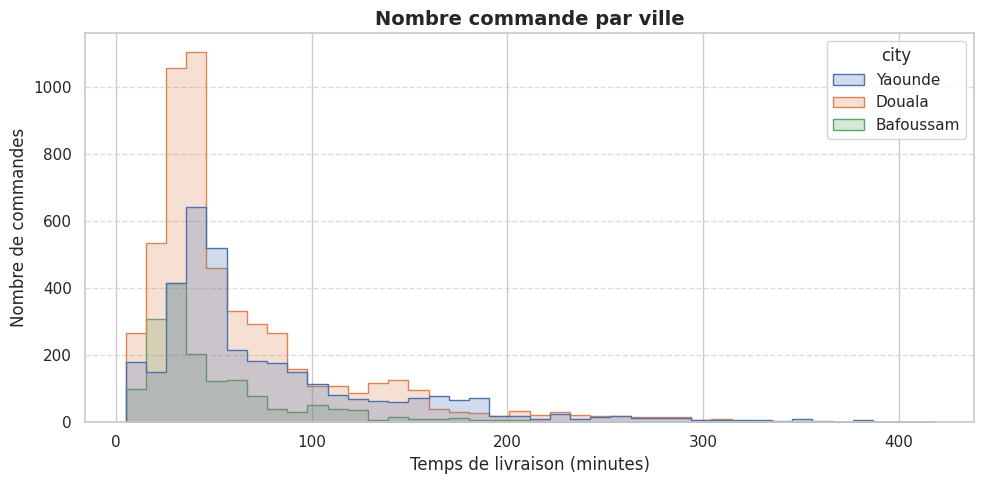

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(
    data=orders.dropna(subset=["delivery_time_min"]),
    x="delivery_time_min",
    hue="city",
    bins=40,
    kde=False,
    element="step"
)
plt.title("Nombre commande par ville", fontsize=14, fontweight='bold')
plt.xlabel("Temps de livraison (minutes)")
plt.ylabel("Nombre de commandes")
plt.grid(axis='y', linestyle='--', alpha=0.7) 
plt.savefig("../reports/statistics/histo_city.png", bbox_inches="tight", dpi=150)
plt.tight_layout()
plt.show()

#### Histogramme par ville


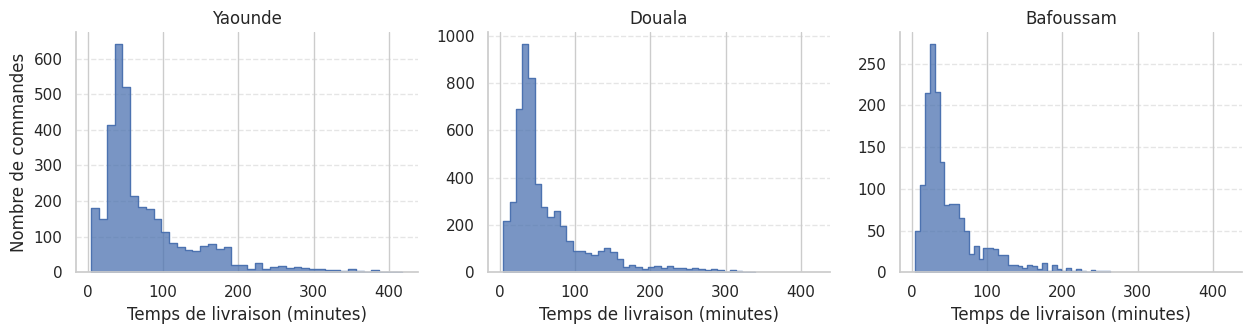

In [ ]:
cities = orders.dropna(subset=["delivery_time_min"])["city"].unique()
g = sns.FacetGrid(
    orders.dropna(subset=["delivery_time_min"]),
    col="city",
    col_wrap=4,          
    sharey=False,          
    height=3.5,
    aspect=1.2
)
g.map_dataframe(sns.histplot, x="delivery_time_min", bins=40, element="step", stat="count", color="C0")
g.set_axis_labels("Temps de livraison (minutes)", "Nombre de commandes")
g.set_titles("{col_name}")
for ax in g.axes.flatten():
    ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("../reports/statistics/histo_per_city.png", bbox_inches="tight", dpi=150)
plt.show()


#### Boxplots temps livraison

/tmp/ipykernel_29297/3928632813.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(


<Figure size 1200x800 with 0 Axes>

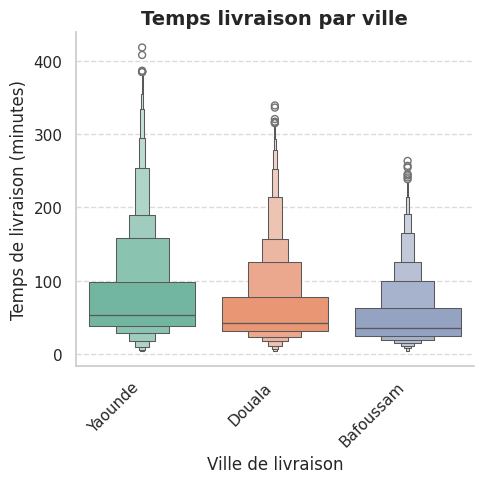

In [ ]:
plt.figure(figsize=(12,8))
sns.catplot(
    data=orders.dropna(subset=["delivery_time_min"]),
    x="city", y="delivery_time_min", kind="boxen",
    palette="Set2"
)

plt.title("Temps livraison par ville", fontsize=14, fontweight='bold')
plt.xlabel("Ville de livraison", fontsize=12)
plt.ylabel("Temps de livraison (minutes)", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.grid(axis='y', linestyle='--', alpha=0.7) 
plt.savefig("../reports/statistics/boxplotVille.png", bbox_inches="tight", dpi=150)
plt.tight_layout()
plt.show()

#### Interprétation du boxplot

Comme le montre notre boxplot coloré, la distribution des temps de livraison à Yaoundé (en vert) est nettement plus étalée et plus haute que celle de Douala (en orange) et bafoussam (en violet). 


## Théorème de Bayes

L'objectif est de `calculer la probabilité qu'une commande soit en retard sachant
qu'elle est passée un vendredi soir à Douala`. 

Le théorème de Bayes est une formule en probabilités qui permet de calculer la probabilité d'un événement, en fonction de connaissances antérieures et de nouvelles preuves ou données. La formule de cet théorème est : P(A|B) = probalité de la preuve B sachant que l'hypothèse A est vraie * la priorité intiale de l'hypothèse A avant d'obtenir la preuve / la probalité générale de la preuve B.
`P(A|B) = P(B|A) * P(A)/ P(B)` 

In [ ]:

df_douala = orders[orders['city'] ==  'Douala'].copy()
df_douala['is_late'] = df_douala['status'] == 'late'

df_douala['is_friday_night'] = (df_douala['order_day_of_week']=='Friday') & (df_douala['order_hour'] >=17)

Proba_A = df_douala['is_late'].mean()
Proba_B = df_douala['is_friday_night'].mean()
Proba_B_with_A = df_douala[df_douala['is_late']]['is_friday_night'].mean()

bayes_result = (Proba_B_with_A * Proba_A) / Proba_B 

resultat = pd.DataFrame({
    "Mesure": [
        "P(Retard Douala)  ",
        "P(Vendredi soir a)",
        "P(Vendredi soir | Retard)",
        "P(Retard | Vendredi soir à Douala)"
    ],
    "Valeur (%)": [
        round(Proba_A*100, 2),
        round(Proba_B*100, 2),
        round(Proba_B_with_A*100, 2),
        f"{bayes_result:.2%}"
    ]
})

print(f"Probabilité de retard le vendredi soir à Douala : {bayes_result:.2%}")
display(resultat)

Probabilité de retard le vendredi soir à Douala : 20.53%


,Mesure,Valeur
0,P(Retard) - Global,0.2242
1,P(Vendredi soir à Douala),0.0331
2,P(Vendredi soir | Retard),0.0303
3,P(Retard | Vendredi soir à Douala),20.53%


### Interprétation 

Sur les données, la probabilité qu'une commande soit en retard sachant que c'etait vendredi soir à Douala est d'environ 20,53%

Le calcul de Bayes nous permet de comprendre la force du lien causal. En calculant P(Vendredi∣Retard), on identifie si le vendredi soir est un prédicteur fiable du retard, ce qui permet d'ajuster les promesses de temps de livraison en temps réel.

## Test de Student

Ici nous devons déterminer si la différence de temps de livraison moyen entre
Douala et Yaoundé est grande en utilisant un niveau de signification (seuil α = 0,05). 

En d'autre terme de comparer les moyenne de Douala et Yaoundé pour déterminer si la différence observée entre elles est vraisemblablement due au hasard ou reflète une vraie différence dans la population avec un niveau de risque d'erreur 5%.  

In [ ]:
df_delivery = (orders['status'] == 'delivered') & (orders['delivery_time_min'] > 0)
dla_data = orders[df_delivery & (orders['city'] == 'Douala')]['delivery_time_min']
yde_data = orders[df_delivery & (orders['city'] == 'Yaoundé')]['delivery_time_min']


t_stat, p_value = ttest_ind(dla_data, yde_data, equal_var=False)

# Moyenne pour l'intepretation
m_dla = dla_data.mean()
m_yde = yde_data.mean()

print(f"Moyenne Douala : {m_dla:.1f} min | Moyenne Yaoundé : {m_yde:.1f} min")
print(f"P-value : {p_value:.4f}")

if p_value < 0.05:
    direction = "plus rapide" if m_dla < m_yde else "plus lente"
    gap = abs(m_dla - m_yde)
    print(f"Significatif : Douala est {direction} de {gap:.1f} min en moyenne.")
else:
    print(" Non significatif : Les deux villes ont des performances similaires.")

Moyenne Douala : 64.09 min
Moyenne Yaoundé : 78.78 min
Différence de moyenne (Douala - Yaoundé) : -14.69 min
p-value : 1.05e-28
Les temps de livraison sont statistiquement différents entre Douala et Yaoundé.

Douala livre plus vite.


#### Interprétation du t-test
Avec les données reçu, dans notre test nous pouvons avoir deux interpretation. 
Si P-value valeur trouvé est inférieur au seuil nous avons :
-  Il y a une différence réelle de performance logistique entre les deux villes. Il ont des temps de livraison distinctes à cause surement de la logistique.

Si supérieur au seuil nous pouvons dire :
- Même si la moyenne de Yaoundé semble plus élevée sur cet échantillon, statistiquement, on ne peut pas affirmer que Yaoundé est plus lente que Douala de manière générale.

En définitive nous pouvons dire que le test students nous montre que les temps de livraison moyens sont significativement différents, celui de douala est signifactivement inférieur à celui de Yaoundé et que Daoula est plus rapide.

## Matrice de corrélation

Ici nous avons pour but de mesurer la force de lien entre les variable (temsp de livraison, score de fidélité, montant de la commande, client et heure de commande), qui vas nous retourner un score compris dans le coéfficient de Pearson (-1 et 1).
- Si nous obtenons 1 nous avons un lien fort.
- Si nous obtenons 0 nous avons pas de lien.
- Si nous obtenons -1 alors si x augmente alors y pourrais diminuer    

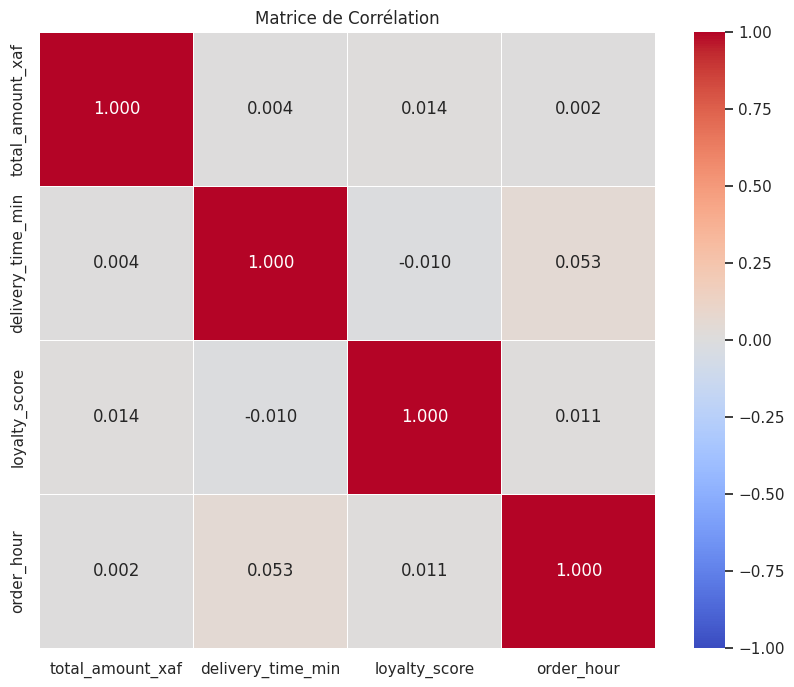

In [151]:
analysis_df = orders.merge(
    customers[["customer_id", "loyalty_score"]],
    on="customer_id",
    how="left"
).copy()

corr_matrix = analysis_df[['total_amount_xaf', 
                           'delivery_time_min', 
                           'loyalty_score',
                           "order_hour"]].corr().round(3)

labels_rename = {
    "total_amount_xaf":  "Montant (XAF)",
    "delivery_time_min": "Délai livraison (min)",
    "loyalty_score":     "Score fidélité",
    "order_hour":        "Heure commande",
}

corr_r = corr_matrix.rename(index=labels_rename, columns=labels_rename)


plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt='.3f', square=True, linewidths=0.5 )
sns.set_theme(style="whitegrid")  
plt.savefig("../reports/statistics/heatmagCorrelation.png", bbox_inches="tight", dpi=150)
plt.title("Matrice de Corrélation")
plt.show()


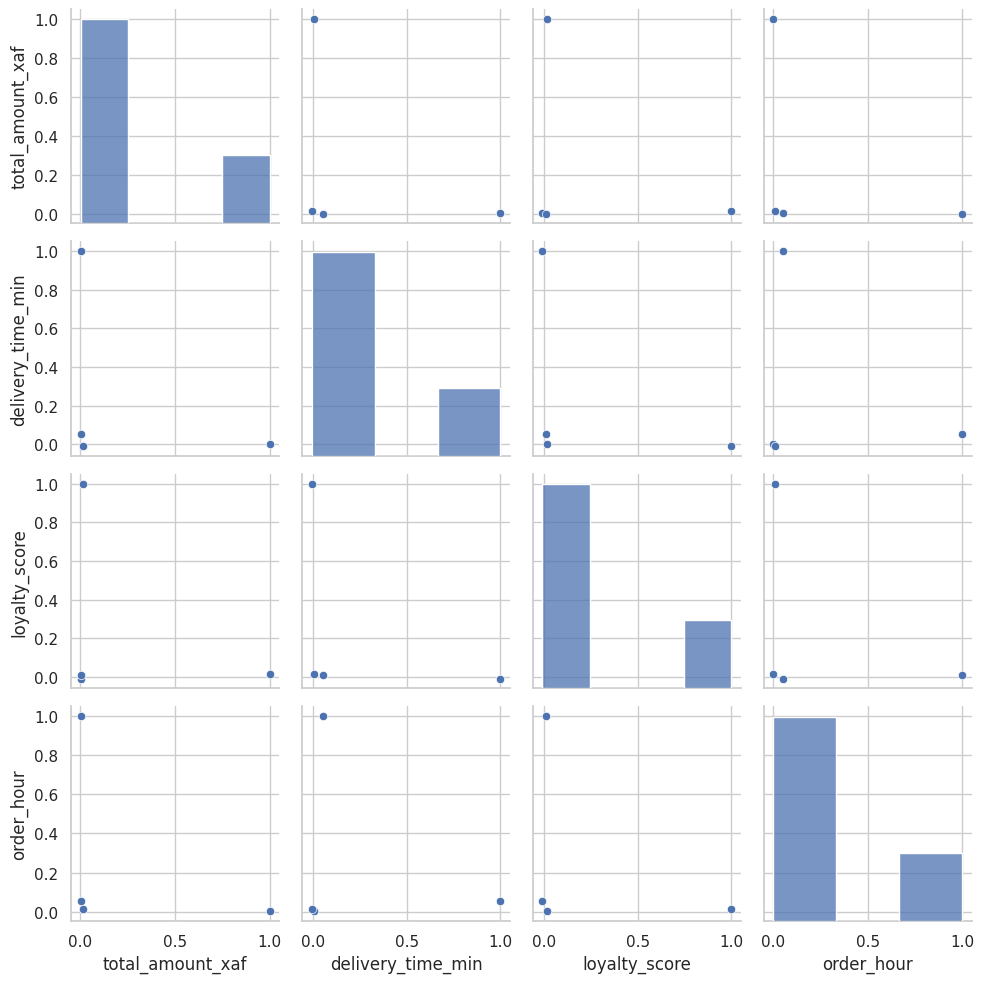

In [148]:
sns.pairplot(corr_matrix, diag_kind="hist")
plt.savefig("../reports/statistics/pairplotCorrelation.png", bbox_inches="tight", dpi=150)
plt.tight_layout()
plt.show()


#### Interprétation des corrélation Forte

nous remarquons globalement que les corrélations sont fiables. Les variables ne montre pas de rélation linéaire forte avec les autres.
- Ici les corrélations forte ce sont sur les memes types.
- Le score de fidélité ne semble pas etre lié au montant ou au temps de livraisons.
- L'heure de commande ne présnte pas ici de corrélation forte avec le temps de livraisons.
- Le montant n'explique pas fortement le temps de livraison


## Détection des outliers avec la méthode IQR

Les outliers sont des valeur aberantes c'est à dire une donnée qui s'éloigne tellement des autres. La méthode IQR (Écart Interquartilles) est une technique pour déterminer ces valeurs. 

Il faudrais alors identifier les valeurs aberrantes des temps de livraison via la méthode **IQR**.

### Rappel mathématique
- \(Q1\) = premier quartile : 25% des livraisons sont plus rapides que cette valeur.

- \(Q3\) = troisième quartile : 75% des livraisons sont plus rapides que cette valeur.

- \(IQR = Q3 - Q1\) : distance entre les deux 

Seuils :
- borne basse = \(Q1 - 1.5 \times IQR\)
- borne haute = \(Q3 + 1.5 \times IQR\)
- borne extreme = \(Q3 + 3.0 \times IQR\)


In [ ]:
# Colonnes temps livraison que nous allons utiliser sans les valeurs nulle
delivery_time = orders["delivery_time_min"].dropna()

# Calcul des bornes et quartile
Q1 = delivery_time.quantile(0.25)
Q3 = delivery_time.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 3.0 * IQR

outliers = orders[
    (orders["delivery_time_min"] < lower_bound) |
    (orders["delivery_time_min"] > upper_bound)
].copy()


#etant donnée qu'on ne pas avoir de valeur négative 
lower_bound = 0
# Construction du tableau de résultats
iqr_results = pd.DataFrame({
    "Mesure": ["Quartile 0.25", "Quartile 0.75", "IQR", "Borne Inférieure", "Borne Supérieure", "Nombre d'outliers"],
    "Valeur": [Q1, Q3, IQR, lower_bound, upper_bound, len(outliers)]
})

display(iqr_results)



,Mesure,Valeur
0,Quartile 0.25,32.00
1,Quartile 0.75,82.25
2,IQR,50.25
3,Borne Inférieure,0.00
4,Borne Supérieure,233.00
5,Nombre d'outliers,266.00


#### Outliers seuil standard et seuil extrême

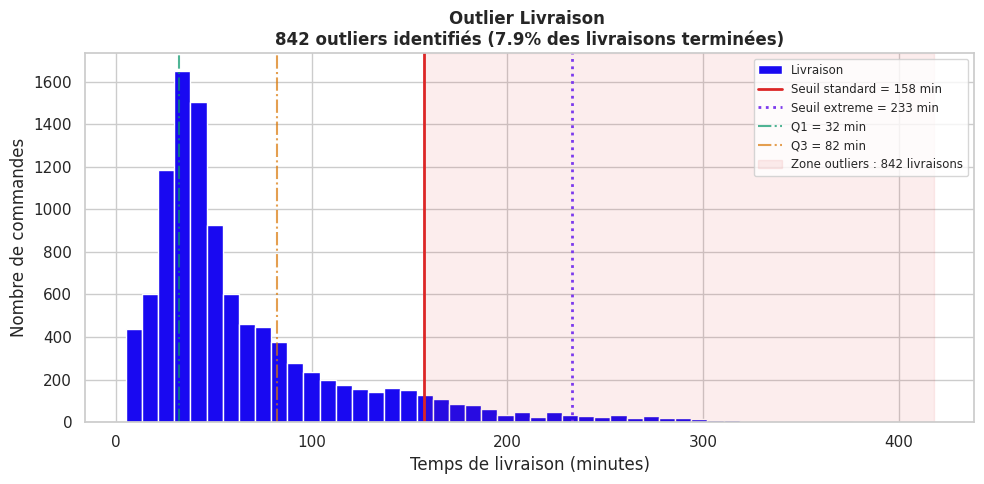

    Douala       :  340 outliers nombre  5442 (6.2%) — Max: 339 min
    Yaounde      :  442 outliers nombre  3519 (12.6%) — Max: 418 min
    Bafoussam    :   60 outliers nombre  1646 (3.6%) — Max: 263 min


In [182]:
fig, ax = plt.subplots(figsize=(10,5))

upper_stand = Q3 + 1.5 * IQR
upper_extre = Q3 + 3.0 * IQR

outliers_stand = delivery_time[delivery_time > upper_stand]
outliers_extre = delivery_time[delivery_time > upper_extre]

ax.hist(delivery_time, bins=50, color="#1909F1", edgecolor="white",
        label="Livraison")
ax.axvline(upper_stand, color="#DC2626", lw=2, ls="-",
           label=f"Seuil standard = {upper_stand:.0f} min")
ax.axvline(upper_extre, color="#7C3AED", lw=2, ls=":",
           label=f"Seuil extreme = {upper_extre:.0f} min")
ax.axvline(Q1, color="#059669", lw=1.5, ls="-.", alpha=0.7,
           label=f"Q1 = {Q1:.0f} min")
ax.axvline(Q3, color="#D97706", lw=1.5, ls="-.", alpha=0.7,
           label=f"Q3 = {Q3:.0f} min")
ax.axvspan(upper_stand, delivery_time.max(), alpha=0.08, color="#DC2626",
           label=f"Zone outliers : {len(outliers_stand):,} livraisons")

dt = orders["delivery_time_min"].dropna()

ax.set_title(
    f"Outlier Livraison \n"
    f"{len(outliers_stand):,} outliers identifiés ({len(outliers_stand)/len(delivery_time)*100:.1f}% des livraisons terminées)",
    fontweight="bold")

ax.set_xlabel("Temps de livraison (minutes)")
ax.set_ylabel("Nombre de commandes")
ax.legend(loc="upper right", fontsize=8.5)

plt.tight_layout()
plt.savefig("../reports/statistics/outliers_iqr.png", bbox_inches="tight", dpi=150)
plt.show()

cities = ["Douala", "Yaounde", "Bafoussam"]

for city in cities:
    outliers_city = orders[
        (orders["city"] == city) &
        (orders["delivery_time_min"] > 0)
    ]["delivery_time_min"].dropna()
    n_out = (outliers_city > upper_stand).sum()
    print(f"    {city:<12} : {n_out:>4} outliers nombre {len(outliers_city):>5} ({n_out/len(outliers_city)*100:.1f}%) — Max: {outliers_city.max():.0f} min")
    

### Interprétation des outliers

Le coefficient 1.5 est le standard statistique. Dans une distribution normale, ce seuil englobe environ 99,3% des données et 3.0 est un standart pour les outliers extrement stricte. Tout ce qui dépasse les deux seuils est considéré comme suffisamment éloigné du centre pour être traité comme une anomalie. Nous pouvons alors dire :
- Les valeurs au dessus de la borne haute est un retard extrêmes.

- Les temps de livraison hors des bornes sont mauvais signes.   

- La meilleur valeur serais la bonne basse, mais elle est négative donc pas de sens. 

- Les valeurs supérieurs au standard extreme doivent etre traités en priorité.

# Conclusion Analytique


Nous allons lister les résultats majeurs de notre analyse : 

-  Les temps de livraison diffèrent nettement selon la ville.

-  Yaoundé apparaît comme la ville la plus lente.

-  La probabilité d'un retad un vendredi soir à Douala est d'environ 22 %.

-  La dífférence entre Douala et Yaoundé est significative par rapport au temps de livraion.

-  Les corrélation entre le temps de livraions, l'heure, le score de fidélité et le montant sont faibles.

-  Les temps de livraison présente un volume important de valeurs.